# Reading the data

In [1]:
loan_data <-
    read.csv(file = "../input/loans-data/loans-3.csv", header=TRUE)
colnames(loan_data)[11] <- "cibil"
str(loan_data)

'data.frame':	3855 obs. of  14 variables:
 $ paid_status   : Factor w/ 2 levels "Paid","Pending Payment": 1 1 1 1 1 1 1 1 1 1 ...
 $ status        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ Age           : int  35 32 27 25 26 27 32 35 24 38 ...
 $ gender        : Factor w/ 2 levels "Female","Male": 2 2 2 2 2 2 2 2 2 2 ...
 $ education     : Factor w/ 4 levels "10th-12th","Graduate",..: 3 4 2 3 3 3 2 4 1 2 ...
 $ married_status: Factor w/ 2 levels "Married","Unmarried": 1 2 2 2 2 2 2 2 2 1 ...
 $ city          : Factor w/ 441 levels "A. C Lane","Adilabad",..: 105 149 334 418 61 324 149 116 241 94 ...
 $ province      : Factor w/ 32 levels "Andhra Pradesh",..: 9 2 9 9 20 19 2 27 20 27 ...
 $ agerange      : Factor w/ 3 levels "<25",">35","25-35": 3 3 3 3 3 3 3 3 1 2 ...
 $ salary        : int  6 4 5 5 3 4 4 4 4 5 ...
 $ cibil         : int  569 734 641 800 616 707 703 797 565 595 ...
 $ appcount      : int  7 8 6 4 5 1 8 4 7 8 ...
 $ phonegrade    : int  1 2 1 3 5 5 5 2 3 5 ...
 $ simstrength   :

* The study variable (y) is the paid_status. It is recoded as a 0-1 variable status. 0 means paid and 1 means 45 days past due (dpd)
* appcount is the count of cash loan applications in the customer's phone. The standard hypothesis is, more the number of cash loan apps, riskier/less disciplined the customer.
* phonegrade is a coded variable which checks the price of the phone model that the customer is using.
* simstrength is also a ranked variable depending on how old the sim card is, daily usage of the phone, number of contacts etc.

In [2]:
head(loan_data)

,paid_status,status,Age,gender,education,married_status,city,province,agerange,salary,cibil,appcount,phonegrade,simstrength
,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>
1,Paid,0,35,Male,Post Graduate,Married,Daskroi,GUJARAT,25-35,6,569,7,1,3
2,Paid,0,32,Male,Self Employed,Unmarried,Guntur,ANDHRA PRADESH,25-35,4,734,8,2,1
3,Paid,0,27,Male,Graduate,Unmarried,Rajkot,GUJARAT,25-35,5,641,6,1,1
4,Paid,0,25,Male,Post Graduate,Unmarried,Vadodara,GUJARAT,25-35,5,800,4,3,3
5,Paid,0,26,Male,Post Graduate,Unmarried,Bhokar,MAHARASHTRA,25-35,3,616,5,5,1
6,Paid,0,27,Male,Post Graduate,Unmarried,Pune,Maharashtra,25-35,4,707,1,5,2


# Exploratory Data Analysis

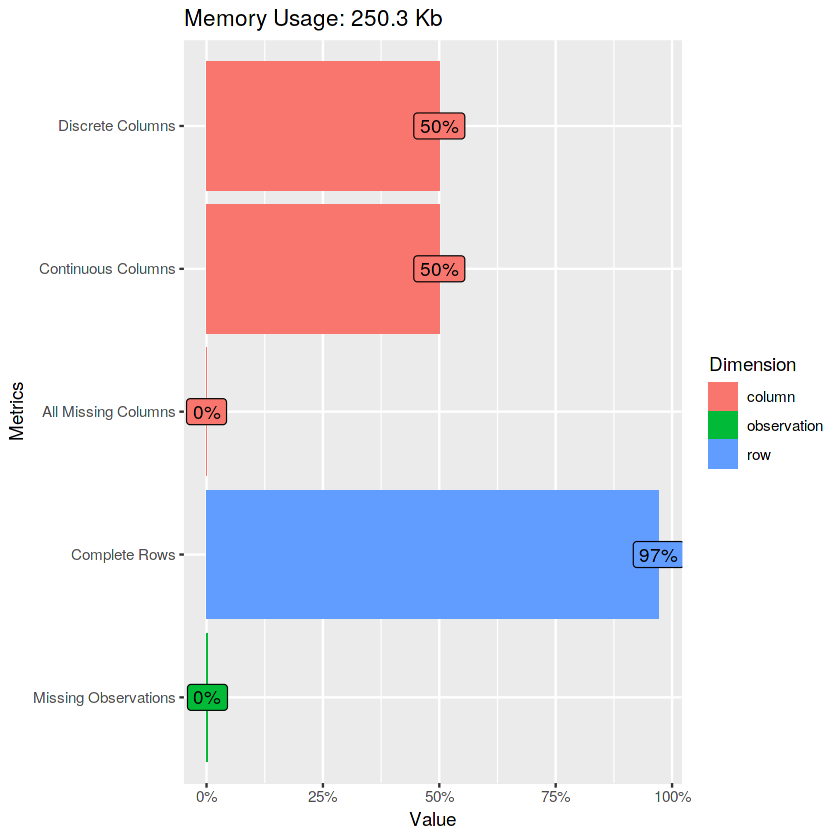

In [3]:
library(DataExplorer)
plot_intro(loan_data)

## Missing values

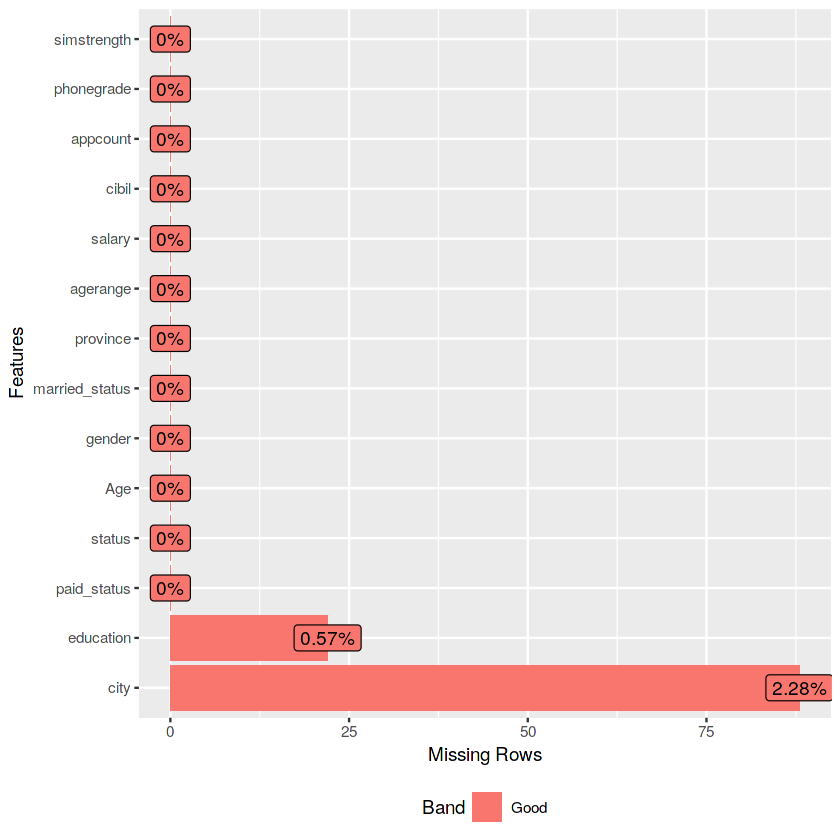

In [4]:
plot_missing(loan_data)

City has 2.29% observations missing and education has 0.57% observations missing.

## Bar plots

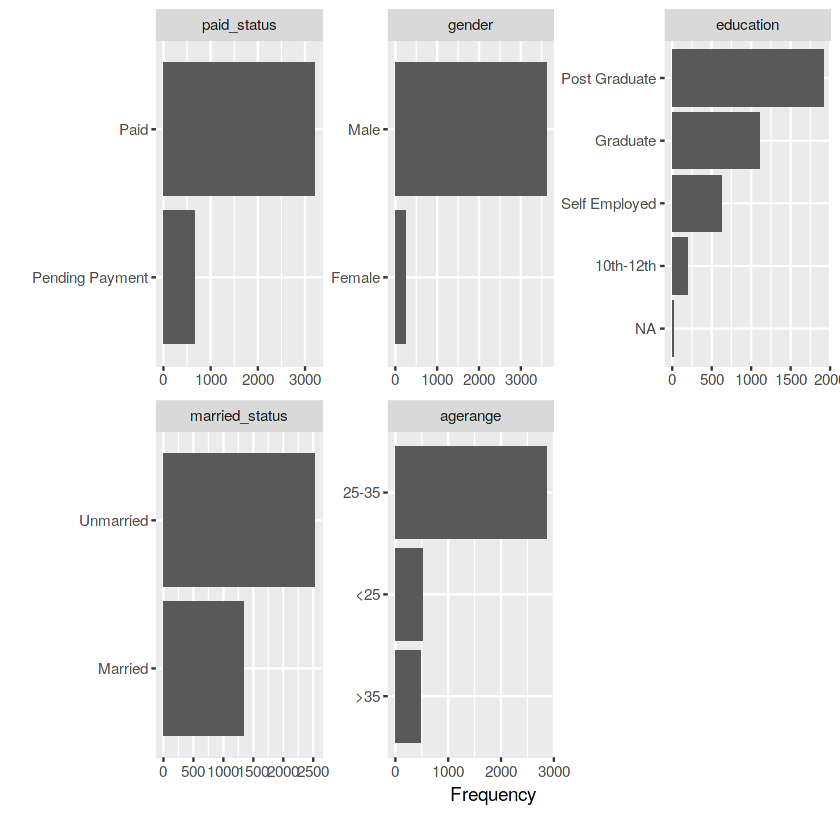

In [5]:
plot_bar(loan_data[,-c(2,7,8)])

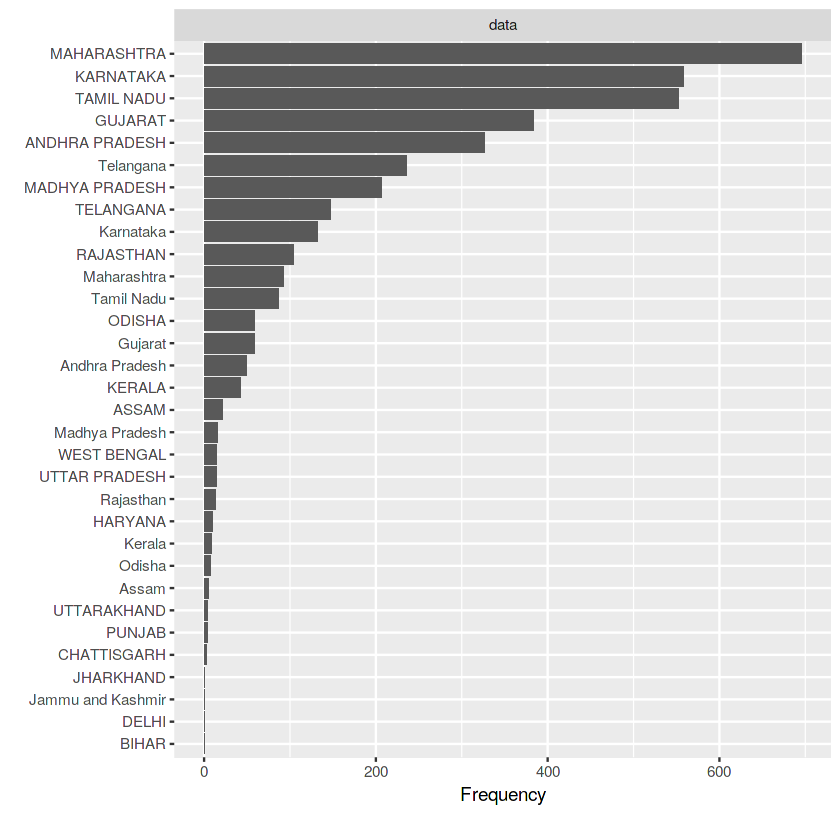

In [6]:
plot_bar(loan_data[,"province"])

There are some states that are repeated due to their case. We need to convert them all to same case.

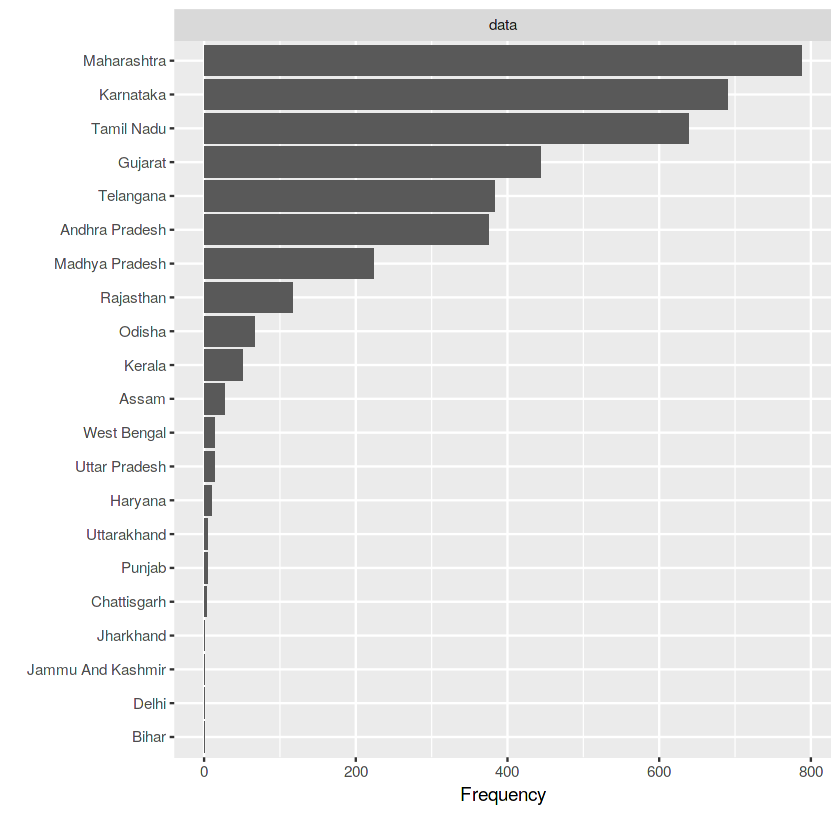

In [7]:
library(stringr)
loan_data[,"province"] <- str_to_title(loan_data[,"province"])
plot_bar(loan_data[,"province"])

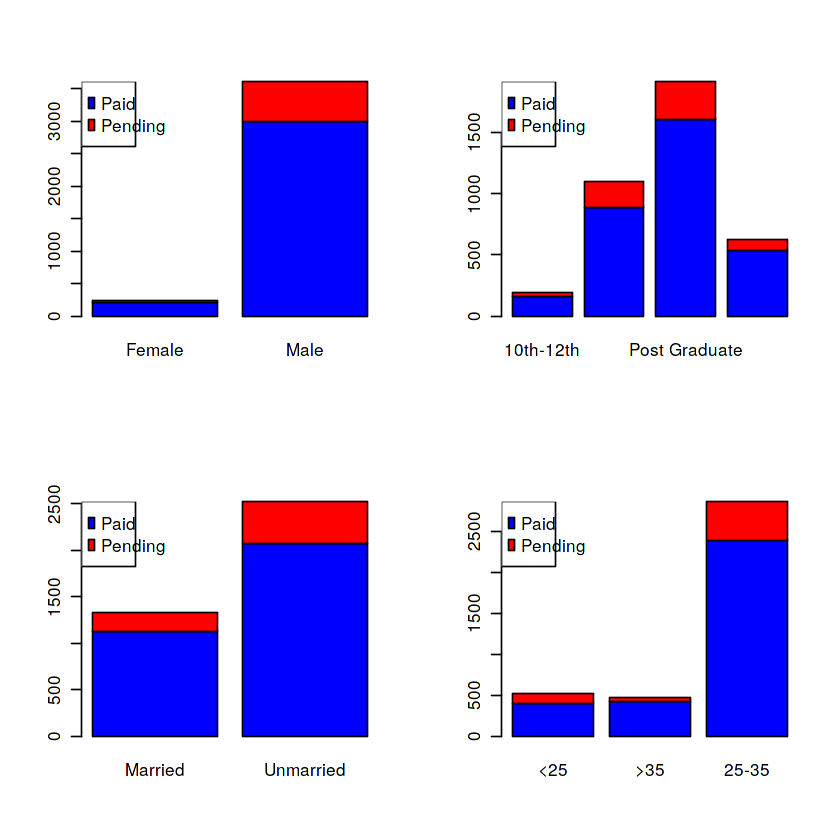

In [8]:
par(mfrow=c(2,2))
barplot(table(loan_data$paid_status, loan_data$gender), col = c("Blue","Red"))
legend("topleft", c("Paid","Pending"), fill = c("Blue","Red"))
barplot(table(loan_data$paid_status, loan_data$education), col = c("Blue","Red"))
legend("topleft", c("Paid","Pending"), fill = c("Blue","Red"))
barplot(table(loan_data$paid_status, loan_data$married_status), col = c("Blue","Red"))
legend("topleft", c("Paid","Pending"), fill = c("Blue","Red"))
barplot(table(loan_data$paid_status, loan_data$agerange), col = c("Blue","Red"))
legend("topleft", c("Paid","Pending"), fill = c("Blue","Red"))

## Histograms

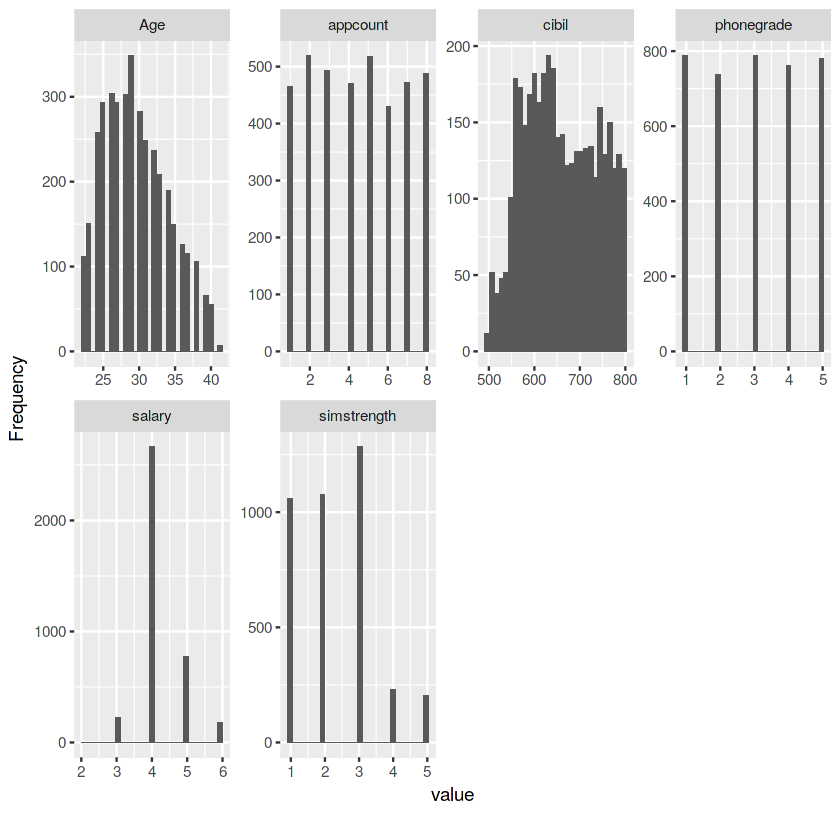

In [9]:
plot_histogram(loan_data)

## Boxplots

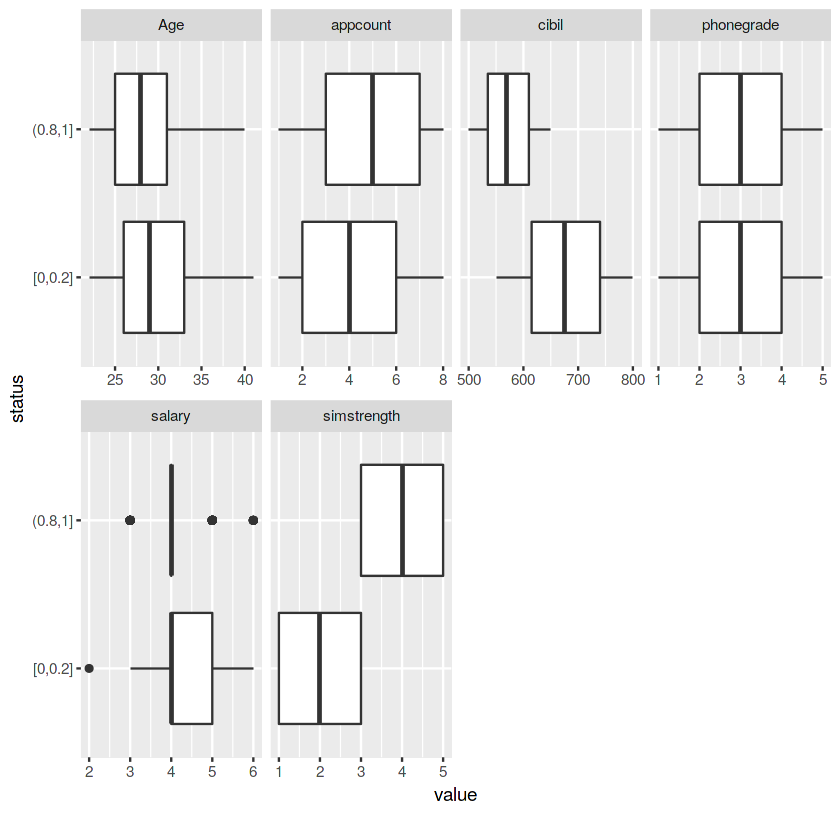

In [10]:
plot_boxplot(loan_data, by="status")

* The boxplot for appcount suggests that the median appcount value for the status 1 (pending payment) is more than that of status 0 (paid), which agrees with our hypothesis.
* The median CIBIL scores are significantly different for defaulters and non defaulters and therefore, CIBIL score is the most important variable for measuring credit risk.
* The median value of simstength is also high for defaulters.

## Correlations

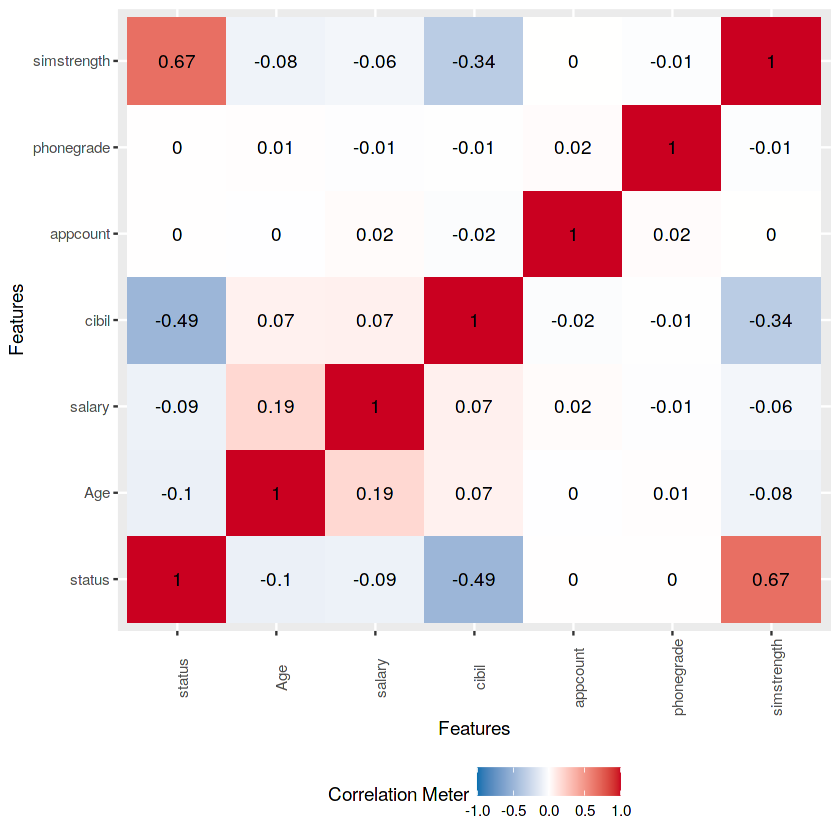

In [11]:
plot_correlation(na.omit(loan_data), type = "c")

* The most correlated variables with status variable are simstength (positive correlation, which means higher the value of simstrength, greater is the chance of default) and CIBIL score (negative correlation, which means higher the CIBIL score, lesser is the chance of default).
* Besides, there is also some negative correlation between these two variables.
* There is also moderate positive correlation between salary and age. Higher the age (implying greater work experience), higher the salary.

# Train test split

In [12]:
set.seed(567)
library(caTools)
loansample <- sample.split(Y = loan_data$status, SplitRatio = 0.8)
train_data <- loan_data[loansample,]
test_data <- loan_data[!loansample,]

# Model Building

In [13]:
options(warn=-1)
options(scipen=999)

log_model <- glm(status ~ gender+married_status+salary+cibil+appcount+phonegrade+simstrength, family = "binomial", data = train_data)
summary(log_model)


Call:
glm(formula = status ~ gender + married_status + salary + cibil + 
    appcount + phonegrade + simstrength, family = "binomial", 
    data = train_data)

Deviance Residuals: 
     Min        1Q    Median        3Q       Max  
-1.54370  -0.04532   0.00000   0.00000   2.47117  

Coefficients:
                            Estimate   Std. Error z value            Pr(>|z|)
(Intercept)              -42.3621028 1902.4440213  -0.022               0.982
genderMale                -0.1548017    0.4543187  -0.341               0.733
married_statusUnmarried    0.1629354    0.2215773   0.735               0.462
salary                    -0.4169823    0.1777752  -2.346               0.019
cibil                     -0.0315220    0.0025544 -12.340 <0.0000000000000002
appcount                  -0.0001363    0.0465024  -0.003               0.998
phonegrade                -0.0828786    0.0747924  -1.108               0.268
simstrength               20.6735466  634.1478042   0.033               0.974

Only salary and cibil are significant variables.

In [14]:
options(warn=-1)
options(scipen=999)

predict <- predict(log_model, test_data, type = 'response')

log_model1 <- glm(status ~ salary+cibil, family = "binomial", data = train_data)
summary(log_model1)


Call:
glm(formula = status ~ salary + cibil, family = "binomial", data = train_data)

Deviance Residuals: 
     Min        1Q    Median        3Q       Max  
-1.43836  -0.51322  -0.18236  -0.06324   2.37619  

Coefficients:
             Estimate Std. Error z value             Pr(>|z|)    
(Intercept) 17.084830   0.886264  19.277 < 0.0000000000000002 ***
salary      -0.266454   0.098474  -2.706              0.00681 ** 
cibil       -0.028528   0.001335 -21.372 < 0.0000000000000002 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2804.7  on 3083  degrees of freedom
Residual deviance: 1838.1  on 3081  degrees of freedom
AIC: 1844.1

Number of Fisher Scoring iterations: 6


# Prediction on test data

In [15]:
predict <- predict(log_model1, test_data, type = 'response')
pred <- factor(ifelse(predict > 0.1,"1","0"), levels = c("0", "1")) # taking 0.1 as the threshold

Our aim is to predict who will default. In this case, a false negative would be a much bigger loss as per business logic. So we decrease the threshold so as to capture maximum defaulters. 

## Confusion matrix

In [16]:
cf <- table(test_data$status, pred)
rownames(cf) <- c("Paid","Pending")
colnames(cf) <- c("Predicted non default","Predicted default")
cf

         pred
          Predicted non default Predicted default
  Paid                      412               228
  Pending                    10               121

## Accuracy

In [17]:
(cf["Paid",1] + cf["Pending",2]) / sum(cf)

[1] 0.69131

## Sensitivity

In [18]:
cf["Pending",2] / (cf["Pending",2] + cf["Pending",1]) 

[1] 0.9236641

The sensitivity of the model is high because of the low threshold which is set in order to catch most of the defaulters in the model.

## ROCR Curve

Loading required package: gplots


Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess




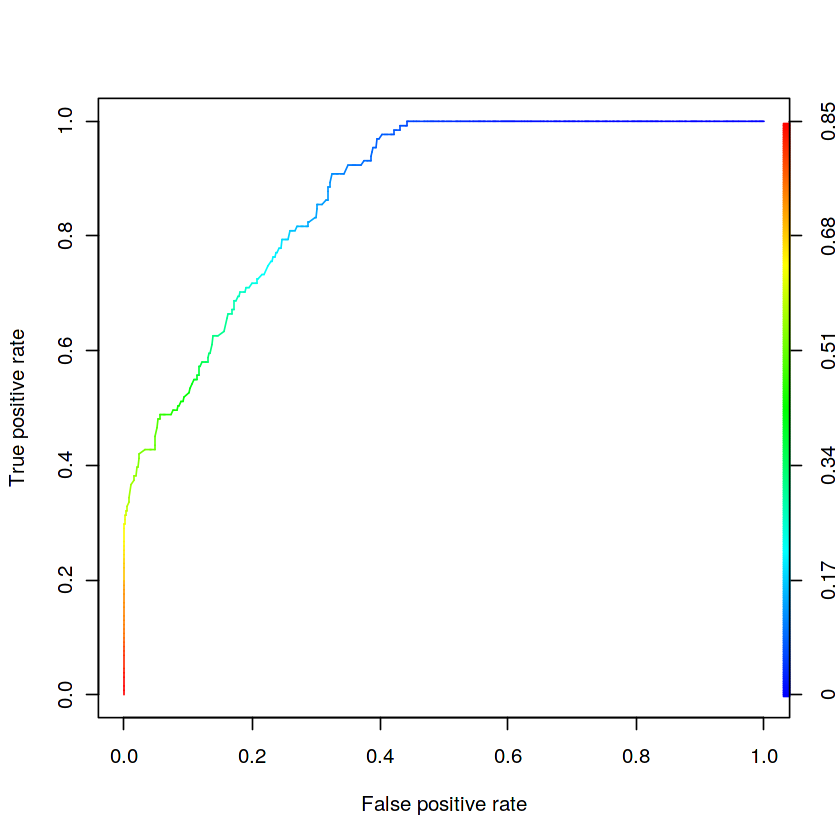

In [19]:
library(ROCR)
ROCRpred <- prediction(predict, test_data$status)
ROCRperf <- performance(ROCRpred, 'tpr','fpr')
plot(ROCRperf, colorize = TRUE, text.adj = c(-0.2,1.7))

### Area under the curve

In [20]:
library(pROC)
auc(roc(test_data$status, as.numeric(as.character(pred))))

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.7837